In [4]:
import pandas as pd

df = pd.read_csv('written-test-2025-06-30-exam-1.csv')

In [29]:
df.dtypes

V0        str
V1    float64
V2    float64
V3    float64
V4    float64
V5    float64
V6    float64
V7    float64
V8    float64
dtype: object

In [30]:
df.head()

,V0,V1,V2,V3,V4,V5,V6,V7,V8
0,ADT1_YEAST,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22
1,ADT2_YEAST,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22
2,ADT3_YEAST,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22
3,AAR2_YEAST,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22
4,AATM_YEAST,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22


In [31]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} features")
print('----------------------------------------------------')
df.info()
print('----------------------------------------------------')
df.describe()

The dataset has 1484 rows and 9 features
----------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V0      1484 non-null   str    
 1   V1      1484 non-null   float64
 2   V2      1484 non-null   float64
 3   V3      1484 non-null   float64
 4   V4      1484 non-null   float64
 5   V5      1484 non-null   float64
 6   V6      1484 non-null   float64
 7   V7      1484 non-null   float64
 8   V8      1484 non-null   float64
dtypes: float64(8), str(1)
memory usage: 104.5 KB
----------------------------------------------------


,V1,V2,V3,V4,V5,V6,V7,V8
count,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000
mean,0.500121,0.499933,0.500034,0.261186,0.504717,0.007500,0.499885,0.276199
std,0.137299,0.123924,0.086670,0.137098,0.048351,0.075683,0.057797,0.106491
min,0.110000,0.130000,0.210000,0.000000,0.500000,0.000000,0.000000,0.000000
25%,0.410000,0.420000,0.460000,0.170000,0.500000,0.000000,0.480000,0.220000
50%,0.490000,0.490000,0.510000,0.220000,0.500000,0.000000,0.510000,0.220000
75%,0.580000,0.570000,0.550000,0.320000,0.500000,0.000000,0.530000,0.300000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.830000,0.730000,1.000000


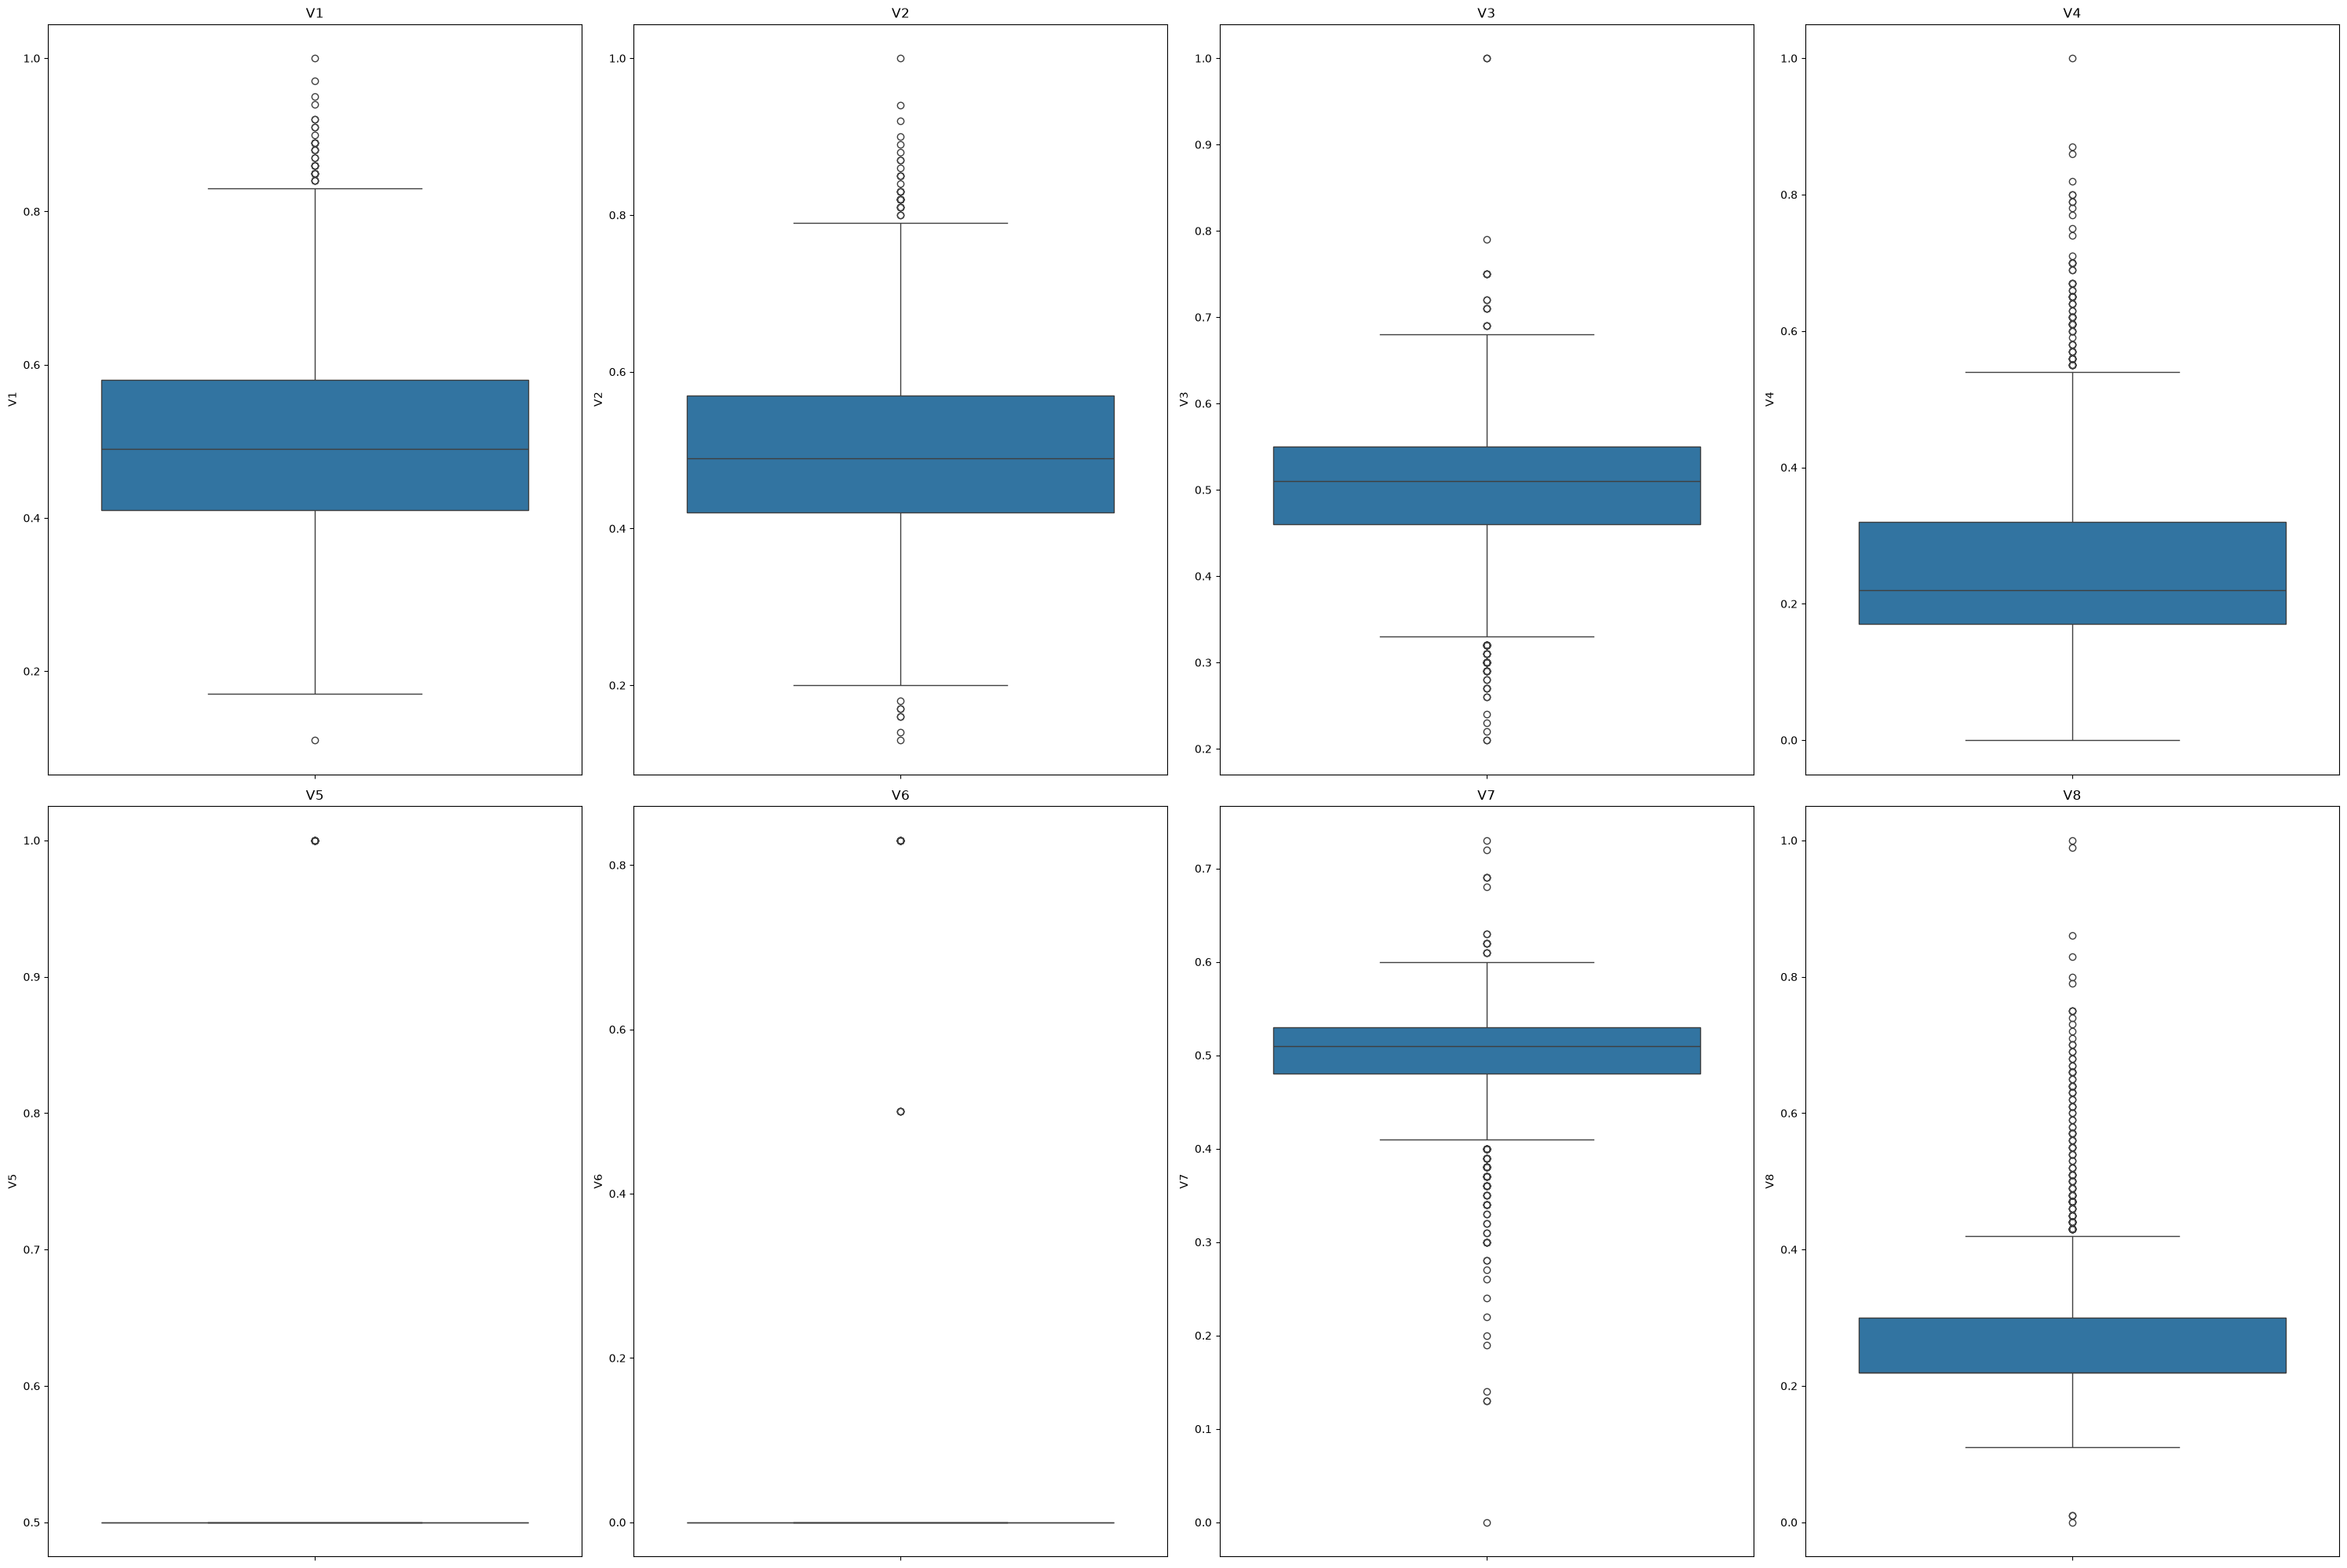

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(30,30))
for pos, col in enumerate(df.columns[1:], start=1):
    plt.subplot(3,4, pos)
    sns.boxplot(df[col])
    plt.title(col)

plt.tight_layout()

In [45]:
df['V8'].describe()

count    1484.000000
mean        0.276199
std         0.106491
min         0.000000
25%         0.220000
50%         0.220000
75%         0.300000
max         1.000000
Name: V8, dtype: float64

In [7]:
df.skew(numeric_only=True)

V1     0.604291
V2     0.416639
V3    -0.220995
V4     1.444776
V5    10.159633
V6    10.276884
V7    -1.791641
V8     2.413031
dtype: float64

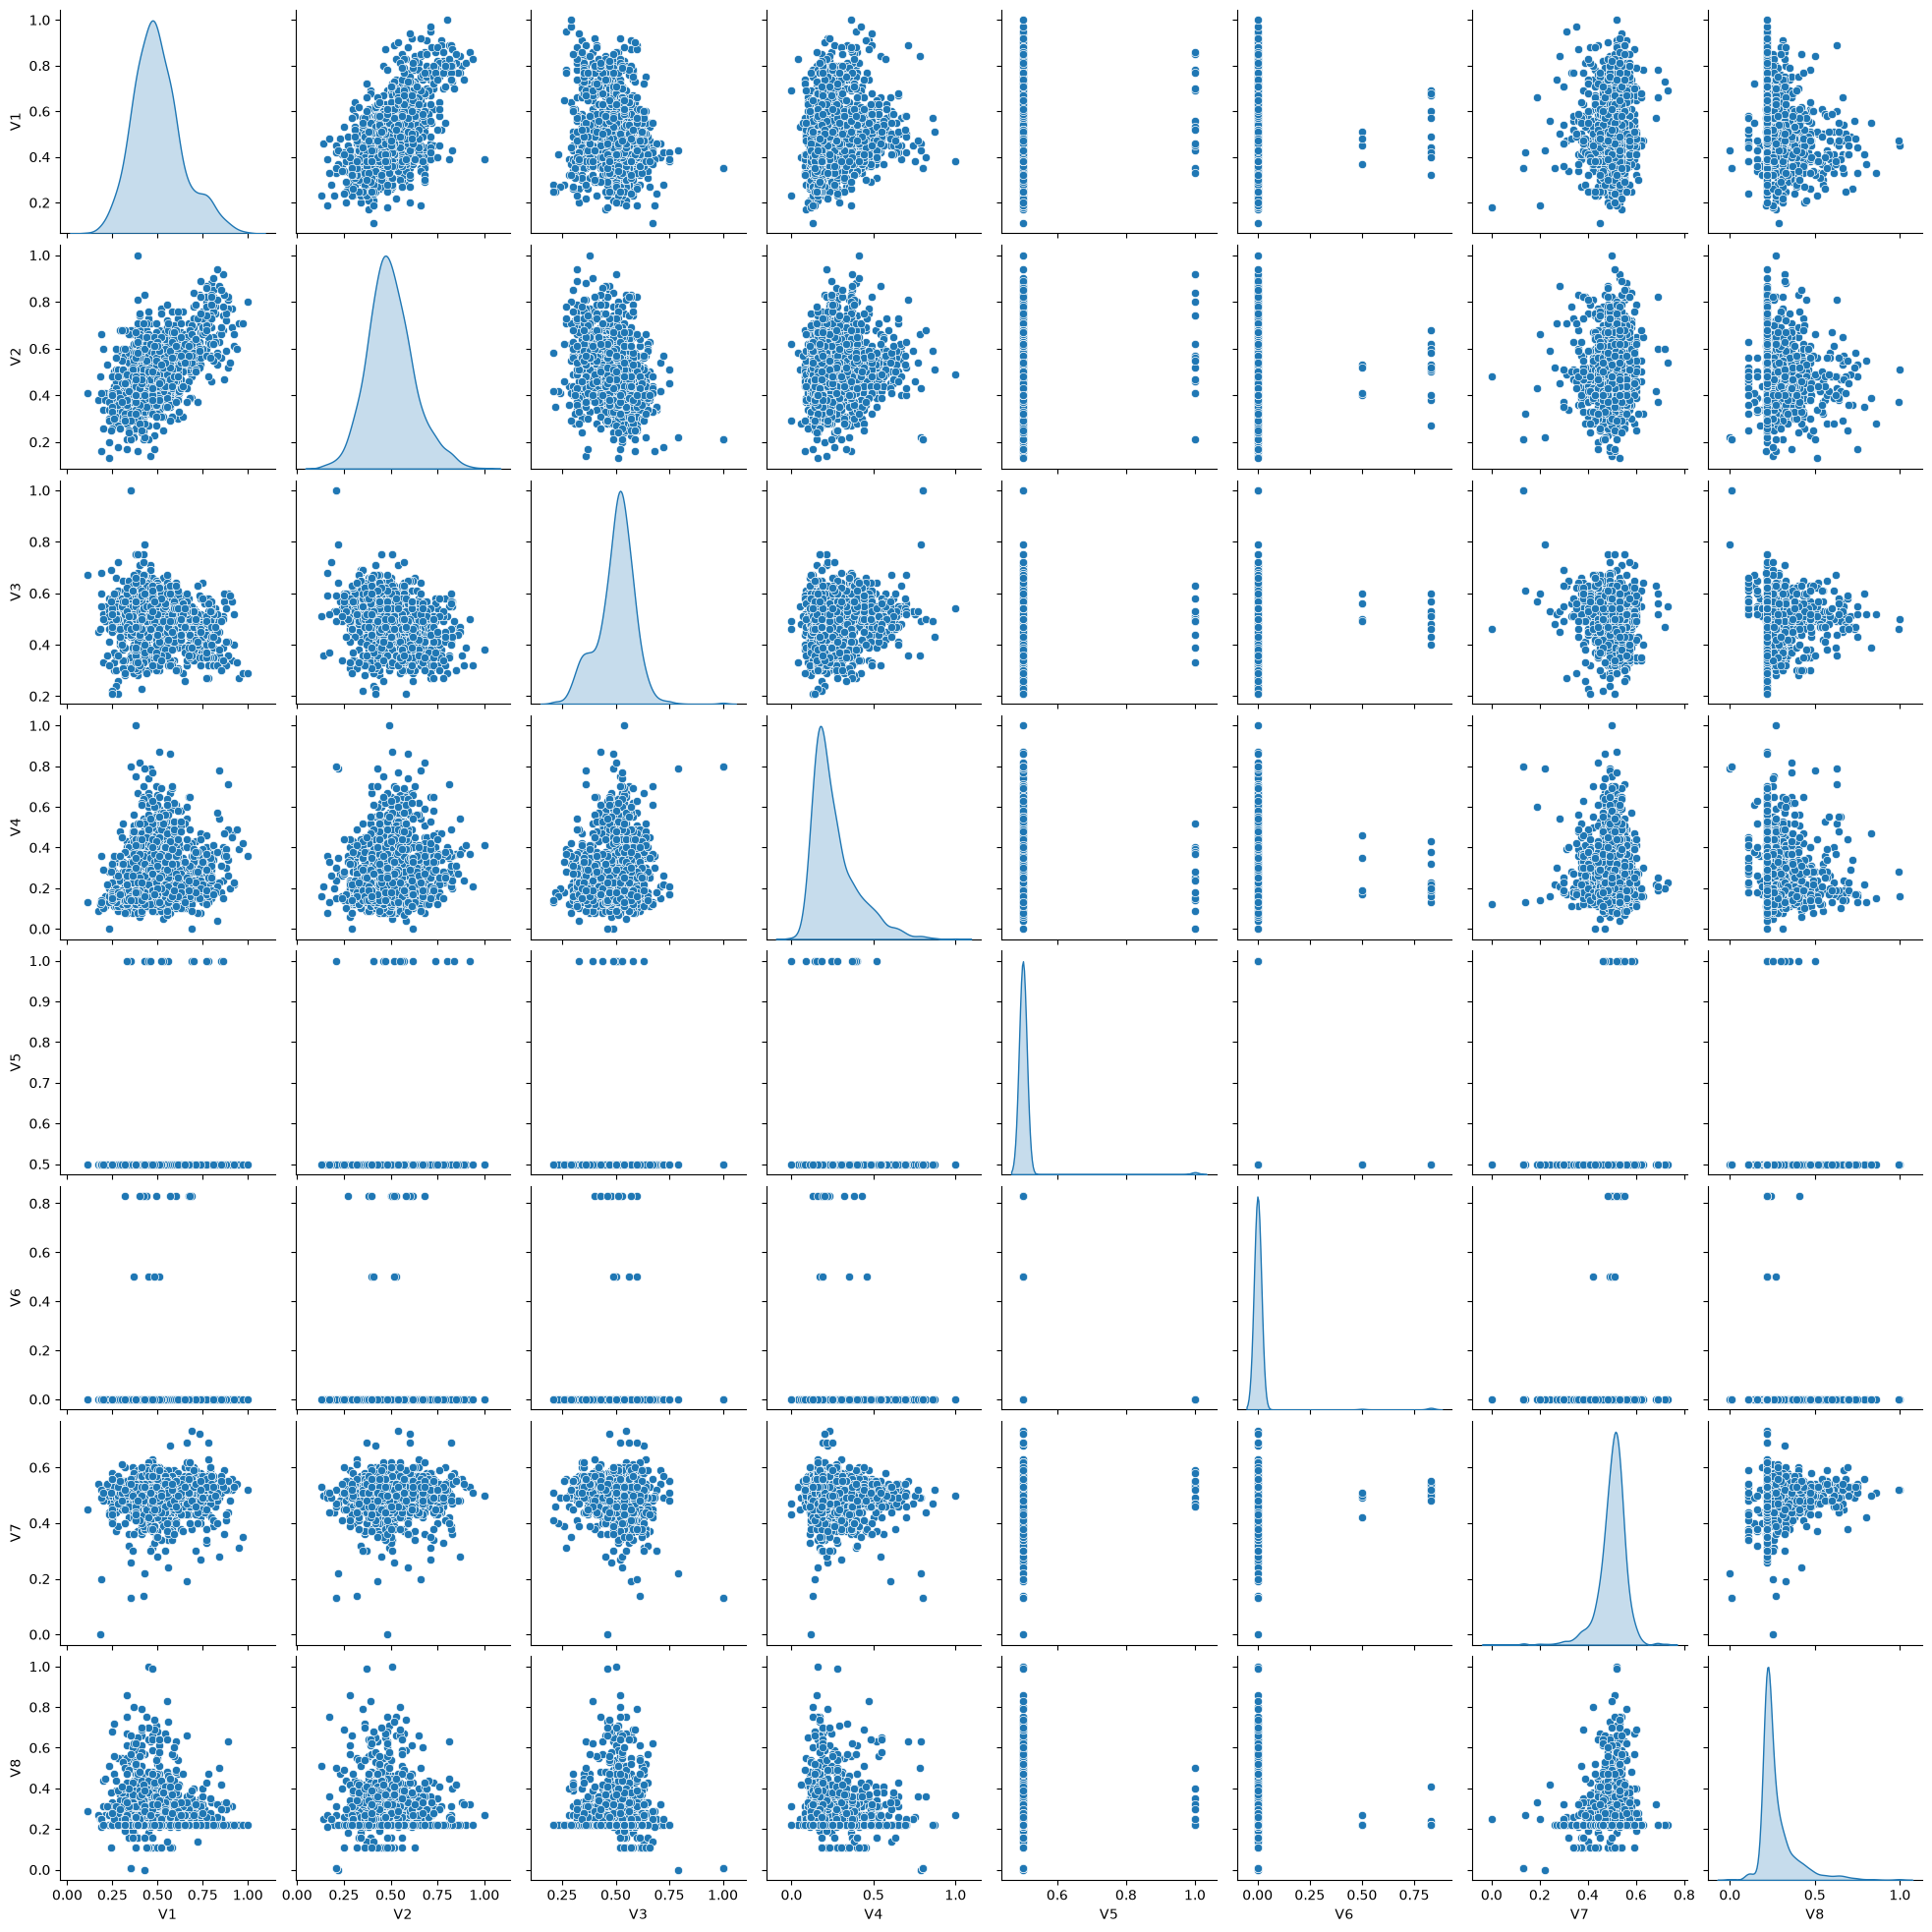

In [44]:
sns.pairplot(df, diag_kind='kde')

V1: Symmetric (median ~0.49 centred in box). Outliers on both fences, more on the upper.

V2: Symmetric (median ~0.49). Outliers on both fences, more on the upper.

V3: Symmetric (median ~0.51, box 0.46–0.55). Outliers on both fences, more on the lower.

V4: Right-skewed. Long upper tail, outliers concentrated on the upper fence.

V5: Near-constant: 1470/1484 records equal 0.5. 14 records differ.

V6: Near-constant: 1469/1484 records equal 0.0. 15 records differ.

V7: Left-skewed with a very narrow IQR (0.48–0.53). Long lower tail.

V8: Right-skewed. 769/1484 records equal 0.22, so median = Q1.

All eight features lie on a 0–1 range, indicating the data is already normalised.

Outliers matter here because KMeans assigns points to the nearest centroid, and a
centroid is a mean — so extreme values pull centroids away from the dense region
and distort cluster boundaries. The objective is to minimise intra-cluster
variance while keeping clusters far apart; outliers work against both.